# Spacing Statistics - RingEnergy

## 1. Importing / Installing Packages

In [1]:
import os # Importing os module for operating system dependent functionality

import glob # Importing glob module for file pattern matching

import pandas as pd # Importing pandas package

import datetime # Importing datetime module for date and time manipulation

# Set the maximum number of columns to display to None
pd.set_option('display.max_columns', None)

from pathlib import Path # Importing Path class from pathlib for filesystem path manipulation

from src.utils import reorder_columns, clean_column_names # Importing utility functions from the utils module

from src.well_data import GeoSurveyProcessor, WellDataLoader, WellSpacingCalculator, DirectionalBenchNeighbors, debug_pair_spacing # Importing custom classes for well data processing

from src.utils import DatabricksOdbcConnector # Importing DatabricksOdbcConnector class from utils module

## 2. Importing Data to Dataframes

In [2]:
def load_uwi_files(folder_path: str) -> pd.DataFrame:
    """
    Reads all .UWI files in the given folder into a single DataFrame.
    
    Parameters
    ----------
    folder_path : str
        Path to the folder containing .UWI files.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['UWI', 'county'].
    """
    all_rows = []

    # Find all .UWI files in the folder
    uwi_paths = glob.glob(os.path.join(folder_path, "*.UWI"))

    for path in uwi_paths:
        county = Path(path).stem  # Extract filename without extension
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            uwis = [line.strip() for line in f if line.strip()]

        print(f"{county}: {len(uwis)} rows")

        for uwi in uwis:
            all_rows.append({"uwi": uwi, "county": county})

    df = pd.DataFrame(all_rows, columns=["uwi", "county"])
    return df

### 2.1 Importing header

In [3]:
data_loader = WellDataLoader(
    db = DatabricksOdbcConnector(),
    log_dir=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\logs"
    )

In [4]:
df_header = data_loader.get_header_data(
    source=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Well Header\uwi_by_county_bench.xlsx",
    column_map={
        "uwi": "uwi",
        "api10":"api10",
        "rsv_cat": "RsvCat",
        "bench": "bench",
        "first_prod_date": "FirstProd_Novi",
        "hole_direction": "HoleDirection_Final",
        "ihs_missing": "IHS_Missing",
        "ihs_ds_missing": "IHS_DS_Missing"
    },
    dtype={"uwi": str, "api10": str}
)

[WellDataLoaderLogger] INFO (08-21 03:33 PM): Loading header data from file: C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Well Header\uwi_by_county_bench.xlsx (Line: 242) [well_data_manager.py]



In [5]:
df_header.shape

(2698, 8)

In [6]:
# Convert 'first_prod_date' to datetime, handling time values as NaT
mask = df_header['first_prod_date'].apply(lambda x: isinstance(x, datetime.time))
df_header.loc[mask, 'first_prod_date'] = pd.NaT
df_header['first_prod_date'] = pd.to_datetime(df_header['first_prod_date'], errors='coerce')

### 2.2 Getting Directional Surveys

In [7]:
# df_directional = data_loader.get_directional_data()

df_directional = pd.read_csv(
    r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Directional Surveys\Directional_Survey.csv",
    dtype={"uwi": str})

In [8]:
df_directional.shape

(312046, 12)

### 2.3 Missing DS from Header

In [9]:
missing_uwi = set(df_header['uwi']) - set(df_directional['uwi'])
print(f"Number of missing UWI: {len(missing_uwi)}")
# list(missing_uwi)

Number of missing UWI: 663


## 3. Computing UTM Coordinates

In [10]:
# Initialize the GeoSurveyProcessor with the log directory
geo = GeoSurveyProcessor(
    log_dir=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\logs")

[GeoLogger] INFO (08-21 03:33 PM): GeoSurveyProcessor initialized. (Line: 477) [well_data_manager.py]



In [11]:
df_utm = geo.compute_utm_coordinates(df=df_directional)

[GeoLogger] INFO (08-21 03:33 PM): ✅ Using lat/lon from input DataFrame. (Line: 653) [well_data_manager.py]

[GeoLogger] INFO (08-21 03:33 PM): ✅ UTM coordinate computation complete in 0.18 sec. (Line: 708) [well_data_manager.py]



In [12]:
# Filter the DataFrame to get only the lateral sections after the heel point
df_utm_lateral = geo.filter_after_heel_point(df=df_utm)

## 4. Calculate Spacing I-K Piars

In [13]:
# Filter the DataFrame based on specific conditions
df_header_filter = df_header[~(df_header["uwi"].isin(missing_uwi)) & 
          (df_header["rsv_cat"].isin(["01PDP", "02PA", "02PDNP", "03PUD"])) &
          ~(df_header["hole_direction"]=="Vertical")].reset_index(drop=True).copy()

In [ ]:
list(set(df_header_filter['uwi']) - set(df_utm_lateral[df_utm_lateral["uwi"].isin(df_header_filter["uwi"].unique())]["uwi"]))

[]

In [15]:
# Create an instance of WellSpacingCalculator with the filtered trajectories
spacing_stats_ik = WellSpacingCalculator(trajectories=df_utm_lateral[df_utm_lateral["uwi"].isin(df_header_filter["uwi"].unique())])

In [16]:
spacing_stats_ik._calculate_spacing_statistics(
    batch_size=200_000,
    max_distance_miles=4.0,
    save_batches_dir=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Spacing Stats",
    max_crossline_ft=3000
)

🚀 Calculating Spacing (Parallel): |████████████████████████████████████████| 100% 2/2 [00:00<00:00]


✅ All batches saved to C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Spacing Stats


In [17]:
df_spacing_ik = spacing_stats_ik._load_saved_batches(
    batch_folder=r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Spacing Stats"
)

🔍 Found 2 batch files. Loading and combining...
✅ Loaded 146,840 rows from all batches.


## 5. Get OneLine

### 5.1 Joining bench with spacing ik dataframe

In [18]:
df_spacing_ik_bench = df_spacing_ik.copy()

bench_map = df_header_filter.set_index("uwi")["bench"]

df_spacing_ik_bench["bench_i"] = df_spacing_ik_bench["well_i"].map(bench_map)
df_spacing_ik_bench["bench_k"] = df_spacing_ik_bench["well_k"].map(bench_map)

df_spacing_ik_bench = reorder_columns(df=df_spacing_ik_bench, columns_to_move=['bench_i', 'bench_k'], reference_column='well_k')
df_spacing_ik_bench = reorder_columns(df=df_spacing_ik_bench, 
                                        columns_to_move=['direction_to_k_from_i_axis','overlap_pct_i', 'overlap_pct_k','overlap_len_common_ft', 'LL_i', 'LL_k'], 
                                        reference_column='3D_dist')

### 5.2 Running oneline

In [19]:
# Filter out rows where 'reject_reason' is not empty
df_spacing_ik_bench_filt = df_spacing_ik_bench[df_spacing_ik_bench["reject_reason"]==""].reset_index(drop=True).copy()

In [20]:
nb = DirectionalBenchNeighbors()

# A) Classic: 1320′ cutoff, any axis, no preference
res_any = nb.summarize(spacing_df=df_spacing_ik_bench_filt, header_df=df_header_filter, 
                       cutoff_ft=1800.0, vertical_cutoff_ft=150.00, 
                       overlap_pct_k_min=0.30)   # require ≥30% of k overlaps with i

# B) Only EW is eligible for *_1, and prefer EW if ties occur
res_ew = nb.summarize(spacing_df=df_spacing_ik_bench_filt, header_df=df_header_filter, 
                      cutoff_ft=1800.0, vertical_cutoff_ft=150.00, overlap_pct_k_min=0.30, # require ≥30% of k overlaps with i
                      axis_mode="EW", prefer_axis="EW")

# C) Any axis is eligible for *_1, but prefer NS on distance ties
res_any_pref_ns = nb.summarize(spacing_df=df_spacing_ik_bench_filt, header_df=df_header_filter, 
                               cutoff_ft=1800.0, vertical_cutoff_ft=150.00, overlap_pct_k_min=0.30, # require ≥30% of k overlaps with i
                               axis_mode="any", prefer_axis="NS")

In [27]:
res_any

,well_i,uwi_same_1,hz_ft_to_same_1,vt_ft_to_same_1,3d_ft_to_same_1,uwi_same_2,hz_ft_to_same_2,vt_ft_to_same_2,3d_ft_to_same_2,uwi_near_1,hz_ft_to_near_1,vt_ft_to_near_1,3d_ft_to_near_1,uwi_near_2,hz_ft_to_near_2,vt_ft_to_near_2,3d_ft_to_near_2
0,30025410040100,30025503690000,933.507723,23.6125,933.806307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,30025421210000,30025426220000,1107.525915,26.0445,1107.832103,30025428730000,1754.503370,46.6605,1755.123721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30025426220000,30025421210000,1107.539330,26.0445,1107.845514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30025428730000,30025421210000,1754.494781,46.6605,1755.115136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30025437350100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,42501376070000,42501376080000,715.778692,9.7000,715.844415,NaN,NaN,NaN,NaN,42501366580000,850.667092,31.890,851.264632,42501371140000,1466.575518,41.6600,1467.167102
1860,42501376080000,42501376070000,715.777839,9.7000,715.843562,42501376100000,824.248755,7.7850,824.285518,42501371140000,756.582689,51.360,758.323952,42501366580000,1572.672532,41.5900,1573.222369
1861,42501376090000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42501366970000,906.587087,68.695,909.185981,42501372890000,1700.058754,31.0685,1700.342618
1862,42501376100000,42501376080000,824.177946,7.7850,824.214713,NaN,NaN,NaN,NaN,42501366270000,695.426828,41.965,696.691850,NaN,NaN,NaN,NaN


In [22]:
df_spacing_ik_bench_filt

,well_i,well_k,bench_i,bench_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,direction_to_k_from_i_axis,overlap_pct_i,overlap_pct_k,overlap_len_common_ft,LL_i,LL_k,drill_direction_i,drill_direction_k,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason,direction_axis,direction_axis_confidence,direction_axis_distribution,axis_forced
0,30025410040100,30025455300000,SAN ANDRES,SAN ANDRES,2834.430974,2836.702875,29.4475,2834.583938,W,0.966272,0.572607,4051.602847,4193.025870,7075.715781,NS,NS,41.0,2803.409515,0.336438,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
1,30025410040100,30025503690000,SAN ANDRES,SAN ANDRES,933.507723,940.956180,23.6125,933.806307,W,1.000000,0.791128,4193.025870,4193.025870,5300.057789,NS,NS,42.0,889.457666,1.111058,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
2,30025410040100,42501364850000,SAN ANDRES,SAN ANDRES,2870.944865,2849.950825,4.1775,2870.947904,E,0.794858,0.783564,3332.859431,4193.025870,4253.461365,NS,NS,34.0,2696.434016,5.870203,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True
3,30025410040100,42501372540000,SAN ANDRES,SAN ANDRES,1505.026059,1505.095305,27.3745,1505.274992,E,0.061805,0.051191,259.151954,4193.025870,5062.409197,NS,NS,3.0,1500.649478,1.592600,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True
4,30025410040100,42501373440000,SAN ANDRES,SAN ANDRES,2918.138197,2920.880702,29.2850,2918.285139,E,0.088816,0.070390,372.409695,4193.025870,5290.682747,NS,NS,4.0,2812.767973,7.202972,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15743,42501376110000,42501373040000,SAN ANDRES,SAN ANDRES,668.991547,677.768394,61.9835,671.856863,E,0.964660,0.998868,4982.741352,5165.280109,4988.388101,NS,NS,50.0,546.092506,2.734059,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True
15744,42501376110000,42501373050000,SAN ANDRES,SAN ANDRES,834.861571,823.656159,46.1885,836.138278,W,0.978777,0.998863,5055.658011,5165.280109,5061.413897,NS,NS,51.0,713.693706,2.580199,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
15745,42501376110000,42501375350000,SAN ANDRES,WOLFCAMP,2093.235707,2095.556100,1.7250,2093.236418,W,0.954892,0.635866,4932.283826,5165.280109,7756.799243,NS,NS,50.0,2039.530034,0.628341,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
15746,42501376110000,42501375360000,SAN ANDRES,WOLFCAMP,2761.563591,2766.038907,25.3250,2761.679711,W,0.995837,0.953752,5143.779023,5165.280109,5393.206482,NS,NS,52.0,2711.309274,0.512467,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True


In [23]:
df_spacing_ik_bench

,well_i,well_k,bench_i,bench_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,direction_to_k_from_i_axis,overlap_pct_i,overlap_pct_k,overlap_len_common_ft,LL_i,LL_k,drill_direction_i,drill_direction_k,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason,direction_axis,direction_axis_confidence,direction_axis_distribution,axis_forced
0,30025410040100,30025421210000,SAN ANDRES,SAN ANDRES,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,0.791400,parallel_like,NaN,NaN,no_overlap_x,EW,NaN,,True
1,30025410040100,30025426220000,SAN ANDRES,SAN ANDRES,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,1.308721,parallel_like,NaN,NaN,no_overlap_x,EW,NaN,,True
2,30025410040100,30025428730000,SAN ANDRES,SAN ANDRES,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,1.222492,parallel_like,NaN,NaN,no_overlap_x,EW,NaN,,True
3,30025410040100,30025435920100,SAN ANDRES,SAN ANDRES,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,0.033931,parallel_like,NaN,NaN,no_overlap_x,EW,NaN,,True
4,30025410040100,30025436820100,SAN ANDRES,SAN ANDRES,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,0.097290,parallel_like,NaN,NaN,no_overlap_x,EW,NaN,,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146835,42501376110000,42501373050000,SAN ANDRES,SAN ANDRES,834.861571,823.656159,46.1885,836.138278,W,0.978777,0.998863,5055.658011,5165.280109,5061.413897,NS,NS,51.0,713.693706,2.580199,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
146836,42501376110000,42501375350000,SAN ANDRES,WOLFCAMP,2093.235707,2095.556100,1.7250,2093.236418,W,0.954892,0.635866,4932.283826,5165.280109,7756.799243,NS,NS,50.0,2039.530034,0.628341,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
146837,42501376110000,42501375360000,SAN ANDRES,WOLFCAMP,2761.563591,2766.038907,25.3250,2761.679711,W,0.995837,0.953752,5143.779023,5165.280109,5393.206482,NS,NS,52.0,2711.309274,0.512467,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True
146838,42501376110000,42501364320000,SAN ANDRES,SAN ANDRES,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,39.597927,oblique,NaN,NaN,coarse_far,EW,NaN,,True


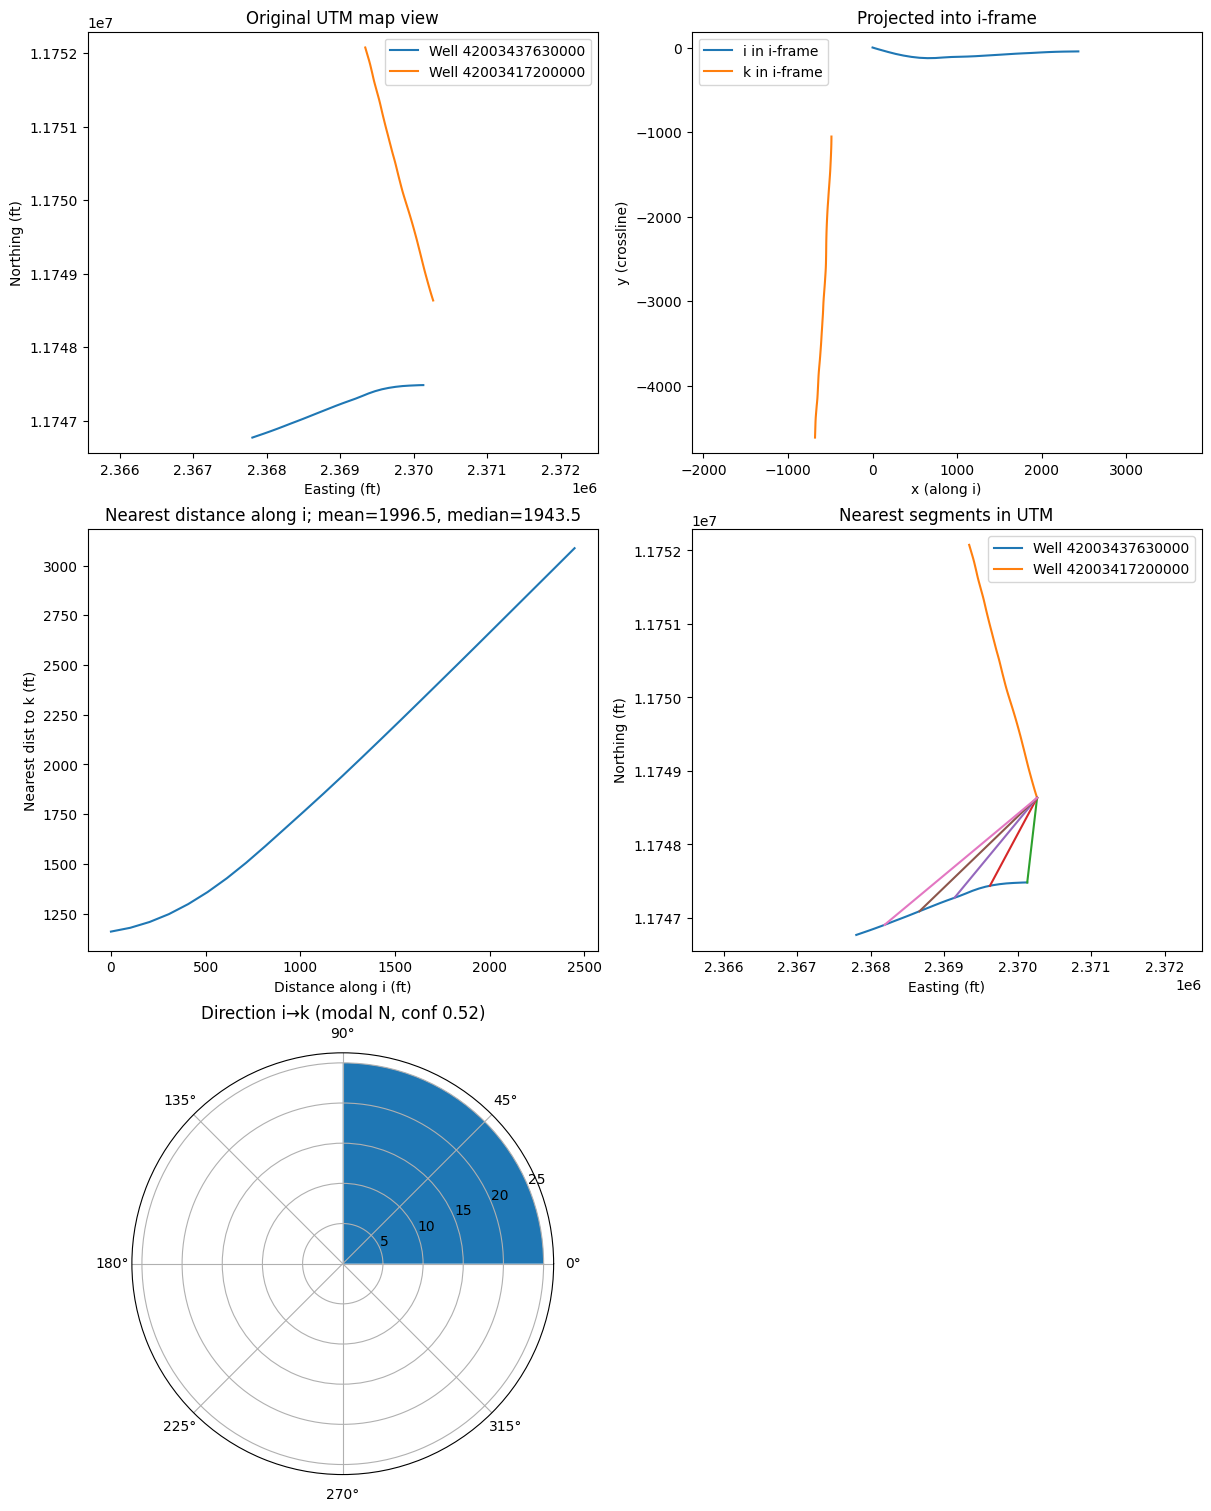

{'pair_alignment': 'perpendicular',
 'angle_deg': 86.83644896012804,
 'paths': {},
 'nearest_mean_ft': 1996.5219054951574,
 'nearest_median_ft': 1943.460621699375,
 'nearest_min_ft': 1159.4057261736552,
 'n_samples': 25,
 'direction_mode_4way': 'N',
 'direction_confidence': 0.52,
 'direction_distribution': {'E': 0.48, 'N': 0.52}}

In [29]:
debug_pair_spacing(
    df=df_utm_lateral,
    uwi_i= "42003437630000",
    uwi_k="42003417200000"
)